# 01 — Exploratory Data Analysis

Goals:
1. Class distribution per horizon — motivates class-weighted training
2. Mid-price over time — confirms temporal structure exists
3. Feature distributions — confirms z-score normalisation
4. Temporal split integrity — confirms no data leakage

In [1]:
import sys, os

PROJECT_ROOT = os.path.expanduser('~/CS372/deeplob-midprice-prediction')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data_loader import load_raw, extract_features_labels, temporal_split, find_stock_boundaries

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

os.makedirs(os.path.join(PROJECT_ROOT, 'results'), exist_ok=True)

## 1. Load data

In [2]:
train_df = load_raw(os.path.join(PROJECT_ROOT, 'data/raw/FI2010_train.csv'))
test_df  = load_raw(os.path.join(PROJECT_ROOT, 'data/raw/FI2010_test.csv'))

X_all, Y_all = extract_features_labels(train_df)
X_test, Y_test = extract_features_labels(test_df)

X_train, Y_train, X_val, Y_val = temporal_split(X_all, Y_all)

print(f'Train:      X={X_train.shape}  Y={Y_train.shape}')
print(f'Validation: X={X_val.shape}    Y={Y_val.shape}')
print(f'Test:       X={X_test.shape}   Y={Y_test.shape}')
print(f'Label values present: {sorted(set(Y_train[:,0].tolist()))}  (should be [0,1,2])')

Train:      X=(308040, 40)  Y=(308040, 5)
Validation: X=(54360, 40)    Y=(54360, 5)
Test:       X=(31937, 40)   Y=(31937, 5)
Label values present: [0, 1, 2]  (should be [0,1,2])


## 2. Class distribution per horizon

The stationary class dominates at every horizon. This directly motivates:
- **Weighted F1** as the primary metric (accuracy would reward always predicting stationary)
- **class_weight='balanced'** in logistic regression
- The majority-class baseline as the performance floor

/var/folders/b9/yk24w6y56dz28m4wkch119pr0000gn/T/ipykernel_81079/4269713734.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fontsize=8)
/var/folders/b9/yk24w6y56dz28m4wkch119pr0000gn/T/ipykernel_81079/4269713734.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fontsize=8)
/var/folders/b9/yk24w6y56dz28m4wkch119pr0000gn/T/ipykernel_81079/4269713734.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fontsize=8)
/var/folders/b9/yk24w6y56dz28m4wkch119pr0000gn/T/ipykernel_81079/4269713734.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabe

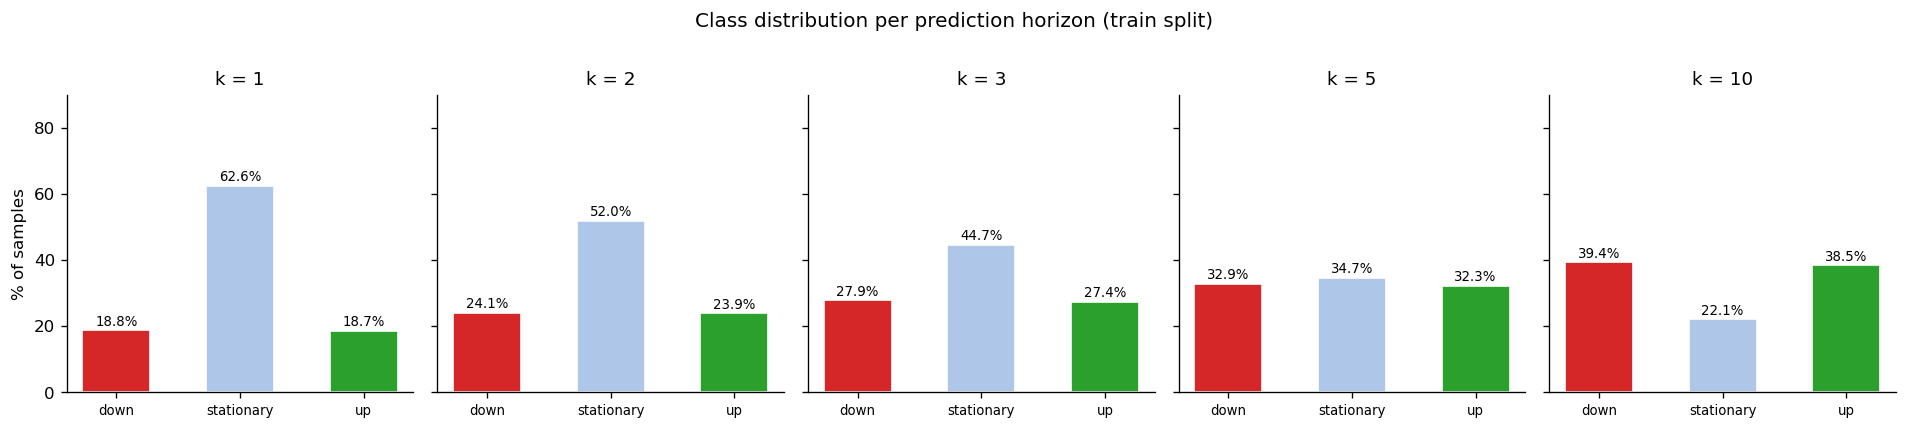


Raw counts (train split):
                      k= 1  k= 2  k= 3  k= 5  k=10
down                   57804   74318   85825  101447  121234
stationary            192753  160157  137781  106982   68142
up                     57483   73565   84434   99611  118664


In [3]:
HORIZONS = [1, 2, 3, 5, 10]
CLASS_NAMES = ['down', 'stationary', 'up']
COLORS = ['#d62728', '#aec7e8', '#2ca02c']

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)
for ax, k, i in zip(axes, HORIZONS, range(5)):
    counts = np.bincount(Y_train[:, i], minlength=3)
    pcts   = counts / counts.sum() * 100
    bars   = ax.bar(CLASS_NAMES, pcts, color=COLORS, width=0.55, edgecolor='white')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'k = {k}', fontsize=11)
    ax.set_ylabel('% of samples' if i == 0 else '')
    ax.set_ylim(0, 90)
    ax.set_xticklabels(CLASS_NAMES, fontsize=8)

fig.suptitle('Class distribution per prediction horizon (train split)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/class_distribution.png'), bbox_inches='tight')
plt.show()

print('\nRaw counts (train split):')
print(f'{"":20}' + ''.join(f'  k={k:>2}' for k in HORIZONS))
for cls, name in enumerate(CLASS_NAMES):
    row = f'{name:20}' + ''.join(f'  {np.bincount(Y_train[:,i], minlength=3)[cls]:>6}' for i in range(5))
    print(row)

## 3. Mid-price over time

FI-2010 concatenates 5 stocks end-to-end with no boundary marker column. Each stock is
z-score normalised independently, so the concatenated series has jarring price jumps at
stock boundaries that are meaningless as a time series.

Stock boundaries are detected via `find_stock_boundaries()`: it finds rows where the
absolute mid-price difference exceeds mean + 10σ of all consecutive differences.

**Per-stock plot** (saved to report): each stock in its own panel, smooth normalised series.  
**Concatenated plot**: kept to show where the detected boundaries fall.

Train boundaries (4 found): [27856, 90663, 147839, 228623]
Test  boundaries (4 found): [1888, 7016, 12738, 18559]


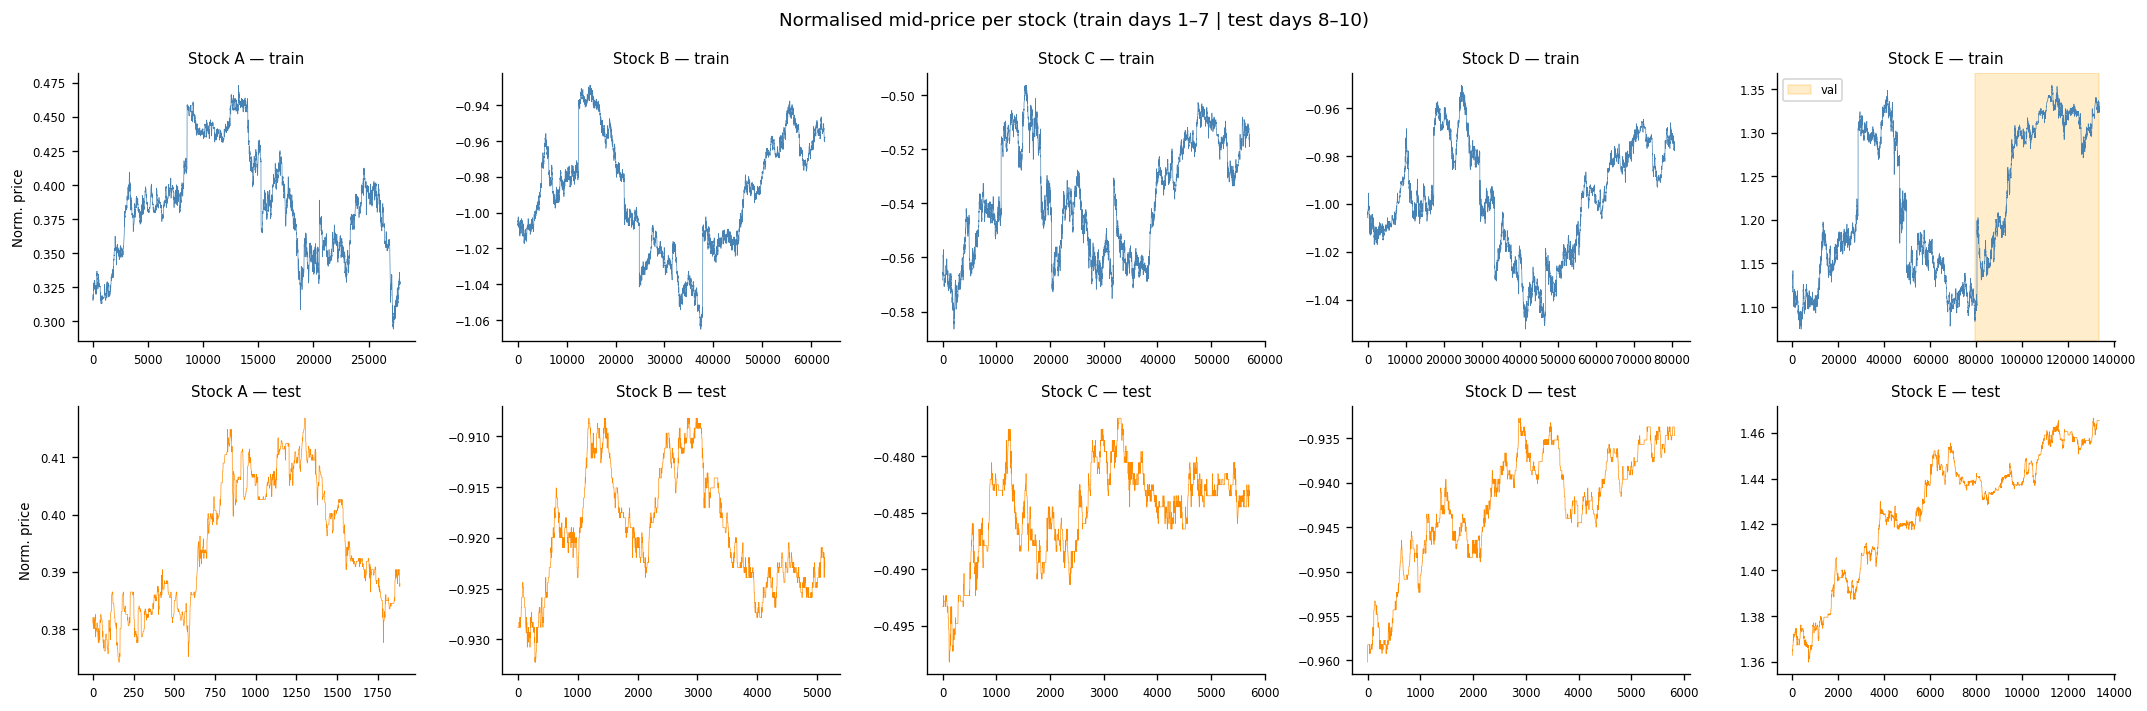

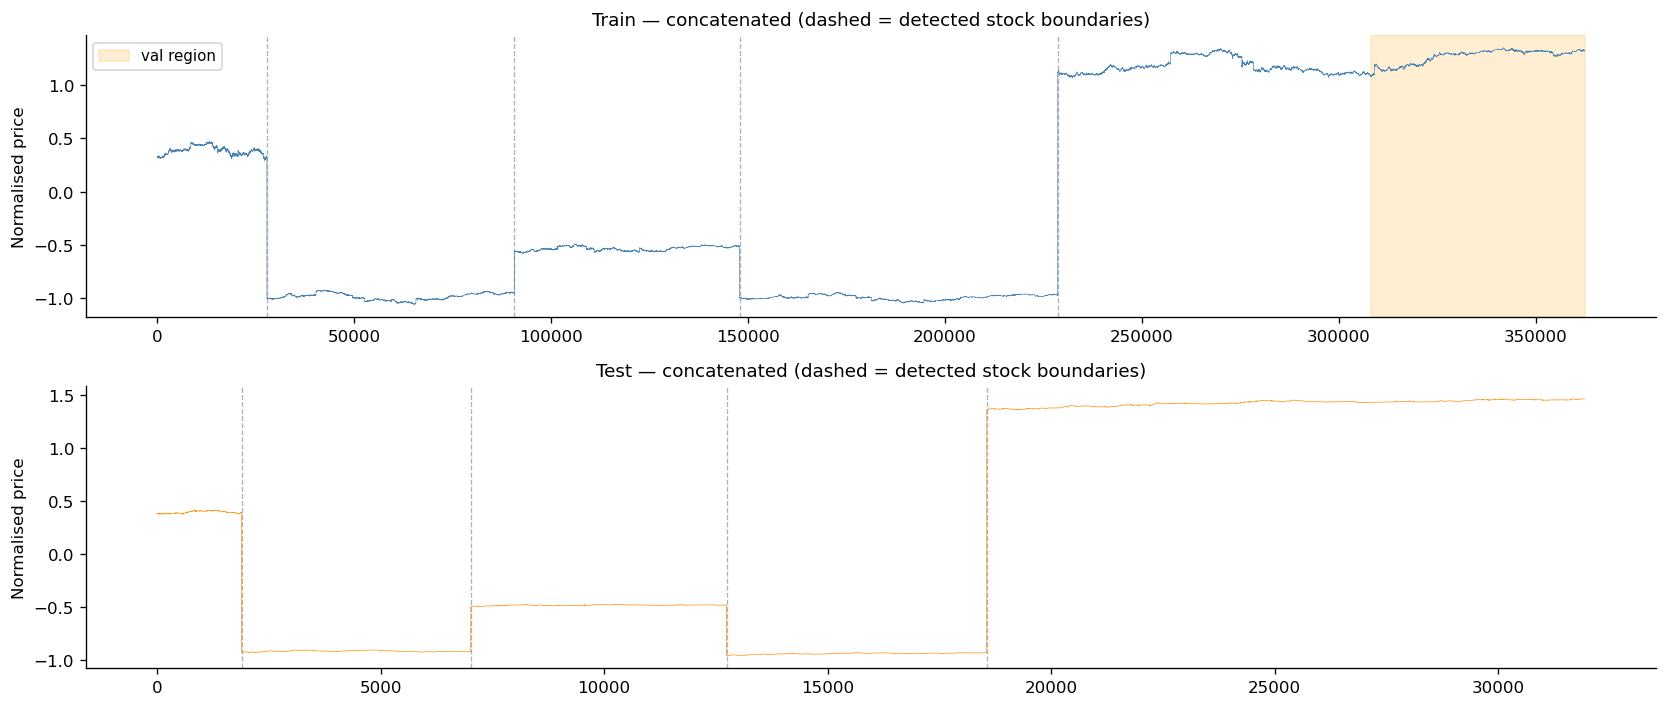

In [4]:
N_STOCKS = 5
STOCK_LABELS = ['Stock A', 'Stock B', 'Stock C', 'Stock D', 'Stock E']

boundaries_train = find_stock_boundaries(X_all)
boundaries_test  = find_stock_boundaries(X_test)
print(f'Train boundaries ({len(boundaries_train)} found): {boundaries_train.tolist()}')
print(f'Test  boundaries ({len(boundaries_test)} found): {boundaries_test.tolist()}')
assert len(boundaries_train) == 4 and len(boundaries_test) == 4, "Expected exactly 4 boundaries per file"

train_splits = np.split(X_all, boundaries_train)
test_splits  = np.split(X_test, boundaries_test)

# Locate which stock contains the train/val boundary and the offset within that stock
cut          = len(X_train)
stock_starts = np.concatenate([[0], boundaries_train])
val_stock    = int(np.searchsorted(stock_starts, cut, side='right')) - 1
val_offset   = cut - stock_starts[val_stock]

# --- Per-stock view (report plot) ---
fig, axes = plt.subplots(2, N_STOCKS, figsize=(18, 6))

for i, (X_s, ax) in enumerate(zip(train_splits, axes[0])):
    mid = (X_s[:, 0] + X_s[:, 2]) / 2
    ax.plot(mid, lw=0.4, color='steelblue')
    if i == val_stock:
        ax.axvspan(val_offset, len(mid), alpha=0.2, color='orange', label='val')
        ax.legend(fontsize=7)
    ax.set_title(f'{STOCK_LABELS[i]} — train', fontsize=9)
    ax.set_ylabel('Norm. price' if i == 0 else '', fontsize=8)
    ax.tick_params(labelsize=7)

for i, (X_s, ax) in enumerate(zip(test_splits, axes[1])):
    mid = (X_s[:, 0] + X_s[:, 2]) / 2
    ax.plot(mid, lw=0.4, color='darkorange')
    ax.set_title(f'{STOCK_LABELS[i]} — test', fontsize=9)
    ax.set_ylabel('Norm. price' if i == 0 else '', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Normalised mid-price per stock (train days 1–7 | test days 8–10)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/mid_price_per_stock.png'), bbox_inches='tight')
plt.show()

# --- Concatenated view (shows detected boundaries) ---
mid_all  = (X_all[:, 0]  + X_all[:, 2])  / 2
mid_test = (X_test[:, 0] + X_test[:, 2]) / 2

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(mid_all, lw=0.4, color='steelblue')
axes[0].axvspan(len(X_train), len(mid_all), alpha=0.18, color='orange', label='val region')
for b in boundaries_train:
    axes[0].axvline(b, color='gray', lw=0.8, ls='--', alpha=0.6)
axes[0].set_title('Train — concatenated (dashed = detected stock boundaries)', fontsize=11)
axes[0].set_ylabel('Normalised price')
axes[0].legend(fontsize=9)

axes[1].plot(mid_test, lw=0.4, color='darkorange')
for b in boundaries_test:
    axes[1].axvline(b, color='gray', lw=0.8, ls='--', alpha=0.6)
axes[1].set_title('Test — concatenated (dashed = detected stock boundaries)', fontsize=11)
axes[1].set_ylabel('Normalised price')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/mid_price_concatenated.png'), bbox_inches='tight')
plt.show()

## 4. Feature distributions

Prices cluster tightly around 0 (z-score does its job). Volume features have heavier tails — large institutional orders create outliers.

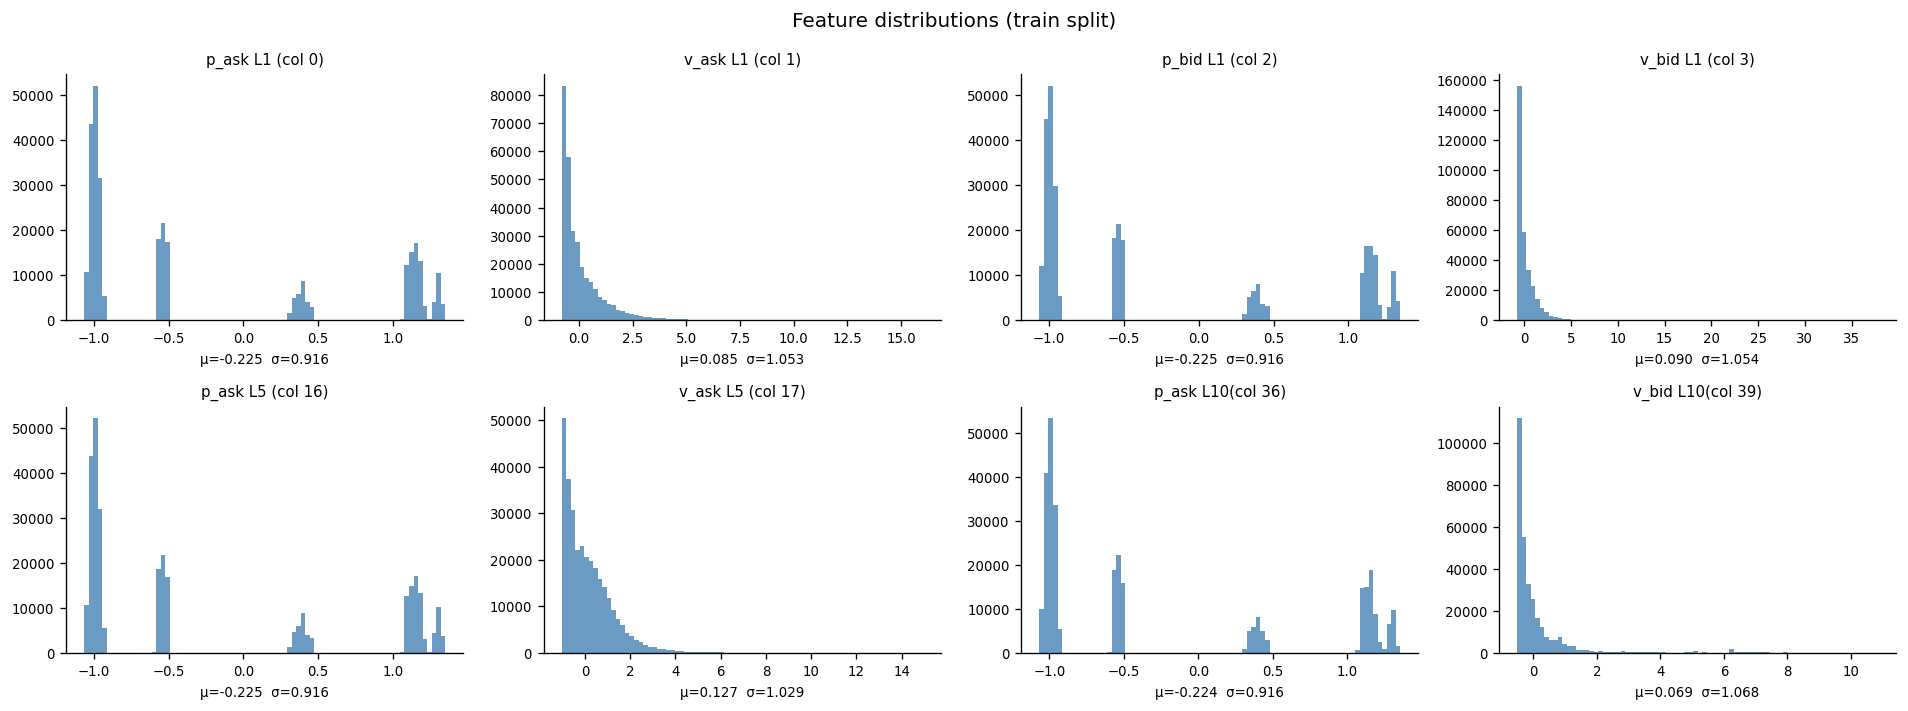

In [7]:
selected = {
    'p_ask L1 (col 0)':   0,
    'v_ask L1 (col 1)':   1,
    'p_bid L1 (col 2)':   2,
    'v_bid L1 (col 3)':   3,
    'p_ask L5 (col 16)':  16,
    'v_ask L5 (col 17)':  17,
    'p_ask L10(col 36)':  36,
    'v_bid L10(col 39)':  39,
}

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (label, col) in zip(axes.ravel(), selected.items()):
    vals = X_train[:, col]
    ax.hist(vals, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel(f'μ={vals.mean():.3f}  σ={vals.std():.3f}', fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle('Feature distributions (train split)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/feature_distributions.png'), bbox_inches='tight')
plt.show()

## 5. Temporal split integrity

Total training-file rows : 362,400
Train ends at row        : 308,039  (85.0%)
Val   starts at row      : 308,040  (15.0%)
Overlap                  : 0 rows  ← strict temporal split confirmed
Label range assertion passed: all labels in {0, 1, 2}


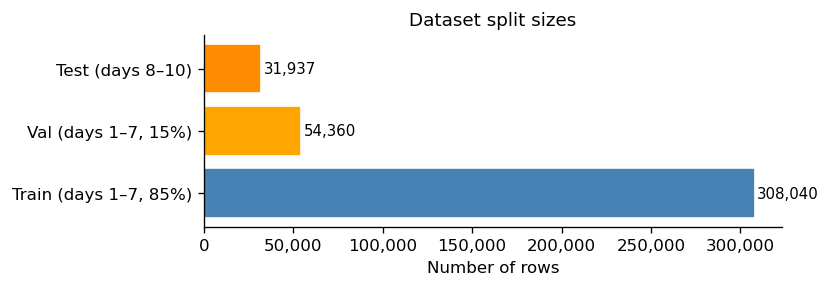

In [8]:
cut = len(X_train)
n   = len(X_all)
print(f'Total training-file rows : {n:,}')
print(f'Train ends at row        : {cut-1:,}  ({cut/n*100:.1f}%)')
print(f'Val   starts at row      : {cut:,}  ({(n-cut)/n*100:.1f}%)')
print(f'Overlap                  : 0 rows  ← strict temporal split confirmed')

assert Y_val.min() >= 0 and Y_val.max() <= 2
print('Label range assertion passed: all labels in {0, 1, 2}')

fig, ax = plt.subplots(figsize=(7, 2.5))
sizes  = [len(X_train), len(X_val), len(X_test)]
labels = ['Train (days 1–7, 85%)', 'Val (days 1–7, 15%)', 'Test (days 8–10)']
bars   = ax.barh(labels, sizes, color=['steelblue', 'orange', 'darkorange'], edgecolor='white')
for bar, s in zip(bars, sizes):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
            f'{s:,}', va='center', fontsize=9)
ax.set_xlabel('Number of rows')
ax.set_title('Dataset split sizes', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results/split_sizes.png'), bbox_inches='tight')
plt.show()

## Summary

Here's the updated summary to replace the old one:
markdown## EDA Summary

**Class imbalance**: At short horizons, stationary dominates heavily — 62.6% of labels at k=1. 
This makes accuracy a useless metric; a model that always predicts stationary scores 62.6% for 
free. Weighted F1 is the correct metric throughout. Importantly, the imbalance shrinks as k 
increases — by k=10 the distribution is nearly uniform (39/22/39), meaning the modeling 
challenge changes substantially across horizons. Class reweighting is essential for short 
horizons.

**Z-score normalization**: Price features are tightly centred near 0 with std ≈ 0.916. Volume 
features show heavier right-skewed tails (std ≈ 1.05) but are bounded and well-behaved. No 
additional normalization is needed — the dataset authors have already handled this.

**Temporal structure**: Per-stock mid-price plots show clear intra-day trends within each stock. 
This motivates sequence models (LSTM, DeepLOB) over snapshot models (LR, XGBoost) — a single 
LOB snapshot carries less information than a window of 100 consecutive snapshots showing how 
the book has evolved.

**Stock concatenation and boundary contamination**: The training file concatenates 5 stocks 
end-to-end with no marker column. Boundary detection via mid-price jump analysis (threshold = 
mean + 10×std) identifies 4 transition points in the training file and 4 in the test file. 
Sliding windows that straddle these boundaries are invalid time series inputs — they splice the 
end of one stock with the start of another. The original DeepLOB reference notebook does not 
handle this. Our implementation skips boundary-crossing windows, affecting ~396 windows out of 
300,000+ (~0.1% of training data). This is a deliberate methodological improvement over the 
reference implementation.

**No data leakage**: Temporal split confirmed with zero overlap — train ends at row 308,039, 
val starts at row 308,040. Test set is a fully separate file (days 8–10).